# Group 63 — Record-Linkage Baselines

## Purpose
Evaluate models that predict whether two records match, using the
supplied precomputed BERT embeddings.

## Models compared
1. Siamese encoder with a fixed distance threshold.
2. A classification head trained on differences between Siamese
   encoder outputs.
3. A separate MLP trained directly on differences between the original
   BERT embeddings, with its decision threshold selected on validation data.

## Data
The notebook uses target training and test pairs from `Datasets/`
and their cached embeddings from `Embeddings/`.

Checks validate embedding structure, label values and agreement between
the target CSV labels and saved embedding labels. Label agreement alone
does not establish that every embedding corresponds to the correct text.

## Relationship to the membership-inference experiment
This notebook measures record-linkage performance.
Membership-inference experiments are implemented separately in
`K_Shadow_Prototype.ipynb`.

Linkage accuracy must not be reported as membership-attack accuracy.
The direct-embedding MLP is a separate baseline from the Siamese target
used in the shadow-model experiment.

## Execution
Keep this notebook in the project root and use the `snn-env` environment.
Precomputed embeddings are used to avoid repeating BERT inference.

Saved outputs document previous executions. A fresh training run may
produce different numerical results.

In [1]:
# Shared dependencies for data checks, linkage models and evaluation.
from pathlib import Path
import json

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
)

print("Imports ready.")
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

Imports ready.
TensorFlow: 2.13.1
NumPy: 1.24.3


In [2]:
# Load the supplied target splits without changing their row order.
# Cached embeddings must remain aligned with these CSV rows.

data_dir = Path("Datasets")

train_df = pd.read_csv(
    data_dir / "target_train.csv",
    dtype={"uid1": str, "uid2": str},
)
test_df = pd.read_csv(
    data_dir / "target_test.csv",
    dtype={"uid1": str, "uid2": str},
)

required_columns = {"uid1", "uid2", "text1", "text2", "label"}

for name, frame in [("Target train", train_df), ("Target test", test_df)]:
    missing = required_columns - set(frame.columns)
    assert not missing, f"{name}: missing columns {sorted(missing)}"

    assert not frame[["uid1", "uid2", "label"]].isna().any().any(), (
        f"{name}: missing record IDs or labels"
    )

    frame["label"] = pd.to_numeric(frame["label"], errors="raise")
    assert frame["label"].isin([0, 1]).all(), (
        f"{name}: linkage labels must be 0 or 1"
    )

    print(f"{name}: {len(frame):,} record pairs loaded.")

Target train: 32,000 record pairs loaded.
Target test: 8,000 record pairs loaded.


## Precomputed embeddings

This notebook loads the team's supplied embedding arrays from `Embeddings/`
instead of regenerating text embeddings during each execution.

Each record pair has:
- `x1`: a 768-dimensional embedding for the first record.
- `x2`: a 768-dimensional embedding for the second record.
- `y`: the linkage label (`1` for a match, `0` for a non-match).

The arrays must preserve the row order of their corresponding source CSVs.
The following checks validate array structure and target-label alignment;
they do not independently verify how the cached embeddings were generated.

The original embedding-generation code is retained in the reference-only Markdown cell below.

### Original embedding-generation code — reference only

```python
# Step 3: Generate embeddings only for train and test separately
# Load pretrained BERT model and tokenizer
from transformers import BertTokenizer, TFBertModel

# Load ClinicalBERT
tokenizer = BertTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
bert_model = TFBertModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")


# Helper function for batched embedding generation
def generate_embeddings_batched(texts, batch_size=32, max_length=512):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts.iloc[i:i+batch_size].tolist()
        inputs = tokenizer(
            batch,
            return_tensors="tf",
            padding=True,
            truncation=True,
            max_length=max_length  # Truncate to 512 tokens
        )
        outputs = bert_model(inputs["input_ids"])
        cls_embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        all_embeddings.append(cls_embeddings.numpy())

    return np.vstack(all_embeddings)
# Encode and save embeddings
x1_train = generate_embeddings_batched(train_df['text1'])
x2_train = generate_embeddings_batched(train_df['text2'])
y_train = train_df['label'].values.astype(np.float32)

x1_test = generate_embeddings_batched(test_df['text1'])
x2_test = generate_embeddings_batched(test_df['text2'])
y_test = test_df['label'].values.astype(np.float32)
```


In [3]:
# Load the supplied cached embeddings without changing row order.
embedding_dir = Path("Embeddings")


def load_embedding_split(name):
    """Load the two record embeddings and linkage labels for a split."""
    arrays = []

    for prefix in ("x1", "x2", "y"):
        path = embedding_dir / f"{prefix}_{name}.npy"
        if not path.is_file():
            raise FileNotFoundError(f"Missing embedding file: {path}")

        arrays.append(np.load(path, allow_pickle=False))

    return tuple(arrays)


# Target arrays are used by the linkage baselines below.
x1_train, x2_train, y_train = load_embedding_split("target_train")
x1_test, x2_test, y_test = load_embedding_split("target_test")

# Shadow arrays are loaded for the existing structural checks only.
# Shadow-model training is performed in K_Shadow_Prototype.ipynb.
x1_shadow_train, x2_shadow_train, y_shadow_train = (
    load_embedding_split("shadow_train")
)
x1_shadow_test, x2_shadow_test, y_shadow_test = (
    load_embedding_split("shadow_test")
)

print("Cached target and shadow embeddings loaded.")
print("Target train:", x1_train.shape, "| Labels:", y_train.shape)
print("Target test:", x1_test.shape, "| Labels:", y_test.shape)
print("Shadow train:", x1_shadow_train.shape, "| Labels:", y_shadow_train.shape)
print("Shadow test:", x1_shadow_test.shape, "| Labels:", y_shadow_test.shape)

assert not np.allclose(x1_test, x2_test), (
    "Target test embedding arrays appear identical; inspect the files."
)

Cached target and shadow embeddings loaded.
Target train: (32000, 768) | Labels: (32000,)
Target test: (8000, 768) | Labels: (8000,)
Shadow train: (32000, 768) | Labels: (32000,)
Shadow test: (8000, 768) | Labels: (8000,)


In [4]:
# Validate all loaded embeddings before training
splits = {
    "Target train": (x1_train, x2_train, y_train),
    "Target test": (x1_test, x2_test, y_test),
    "Shadow train": (x1_shadow_train, x2_shadow_train, y_shadow_train),
    "Shadow test": (x1_shadow_test, x2_shadow_test, y_shadow_test),
}

for name, (a, b, labels) in splits.items():
    assert a.ndim == b.ndim == 2, f"{name}: embeddings must be matrices"
    assert labels.ndim == 1, f"{name}: labels must be one-dimensional"
    assert a.shape == b.shape == (len(labels), 768), f"{name}: shape mismatch"
    assert np.isfinite(a).all() and np.isfinite(b).all(), f"{name}: NaN/Inf"
    assert np.isin(labels, [0, 1]).all(), f"{name}: invalid labels"

    values, counts = np.unique(labels, return_counts=True)
    print(f"{name}: {len(labels):,} pairs | labels: {dict(zip(values, counts))}")

print("All four splits passed structural checks.")

Target train: 32,000 pairs | labels: {0.0: 16031, 1.0: 15969}
Target test: 8,000 pairs | labels: {0.0: 4008, 1.0: 3992}
Shadow train: 32,000 pairs | labels: {0.0: 15969, 1.0: 16031}
Shadow test: 8,000 pairs | labels: {0.0: 3992, 1.0: 4008}
All four splits passed structural checks.


In [5]:
# Check cached target labels against the CSVs already loaded above.
# Matching labels are necessary, but do not prove text-to-embedding alignment.

for name, frame, saved_labels in [
    ("Target train", train_df, y_train),
    ("Target test", test_df, y_test),
]:
    csv_labels = frame["label"].to_numpy()

    assert len(frame) == len(saved_labels), (
        f"{name}: CSV and embedding-label row counts differ"
    )

    mismatches = np.count_nonzero(csv_labels != saved_labels)
    print(f"{name}: {mismatches} label mismatches")

    assert mismatches == 0, (
        f"{name}: CSV labels and cached labels do not align"
    )

print("Target CSV and cached labels agree row by row.")

Target train: 0 label mismatches
Target test: 0 label mismatches
Target CSV and cached labels agree row by row.


In [6]:
# Define the shared encoder and decoder used for pairwise training.
# This cell defines the model; it does not train it.

def build_siamese_autoencoder(embedding_dim):
    """Build the Siamese model and return its shared encoder."""
    encoder_input = Input(shape=(embedding_dim,))

    hidden = layers.Dense(
        50,
        activity_regularizer=regularizers.l1(0.01),
    )(encoder_input)
    hidden = layers.LeakyReLU(alpha=0.01)(hidden)
    encoder_output = layers.Dense(
        embedding_dim, activation="relu"
    )(hidden)

    encoder = Model(encoder_input, encoder_output)

    decoder_input = Input(shape=(embedding_dim,))
    decoder_output = layers.Dense(
        embedding_dim, activation="sigmoid"
    )(decoder_input)
    decoder = Model(decoder_input, decoder_output)

    # Both records use the same encoder and decoder weights.
    input1 = Input(shape=(embedding_dim,))
    input2 = Input(shape=(embedding_dim,))

    decoded1 = decoder(encoder(input1))
    decoded2 = decoder(encoder(input2))

    paired_outputs = layers.Concatenate()([decoded1, decoded2])
    siamese_model = Model(
        inputs=[input1, input2],
        outputs=paired_outputs,
    )

    return siamese_model, encoder


def hybrid_classification_loss(margin=2.5, alpha=1.0):
    """Combine decoded-pair difference and contrastive loss."""
    def loss_fn(y_true, y_pred):
        embedding_dim = tf.shape(y_pred)[1] // 2
        left = y_pred[:, :embedding_dim]
        right = y_pred[:, embedding_dim:]

        squared_difference = tf.square(left - right)
        pair_difference_loss = tf.reduce_mean(
            squared_difference, axis=1
        )
        squared_distance = tf.reduce_sum(
            squared_difference, axis=1
        )

        # Avoid an unstable square-root gradient at zero.
        distances = tf.sqrt(
            tf.maximum(squared_distance, tf.keras.backend.epsilon())
        )

        # Use one linkage label per pair, preventing label broadcasting.
        labels = tf.reshape(tf.cast(y_true, y_pred.dtype), [-1])
        tf.debugging.assert_equal(
            tf.shape(labels)[0],
            tf.shape(y_pred)[0],
        )

        # Matching pairs are pulled together; non-matches use a margin.
        contrastive_loss = (
            labels * squared_distance
            + (1 - labels)
            * tf.square(tf.maximum(margin - distances, 0))
        )

        # This compares decoded outputs with each other.
        # It does not reconstruct the original input embeddings.
        return tf.reduce_mean(
            alpha * pair_difference_loss + contrastive_loss
        )

    return loss_fn


print("Siamese architecture and loss definitions ready.")

Siamese architecture and loss definitions ready.


In [7]:
# Build and train the Siamese encoder before evaluating its outputs.
# Training settings restored from the original notebook.

embedding_dim = x1_train.shape[1]

sa_model, encoder = build_siamese_autoencoder(embedding_dim)
sa_model.compile(
    optimizer="adam",
    loss=hybrid_classification_loss(margin=2.5, alpha=1.0),
)

# Reserve 10% of the supplied training split for validation.
# The external target test set is not used during training.
siamese_history = sa_model.fit(
    [x1_train, x2_train],
    y_train,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    verbose=2,
    callbacks=[tf.keras.callbacks.TerminateOnNaN()],
)

assert np.isfinite(siamese_history.history["loss"]).all(), (
    "Non-finite Siamese training loss"
)
assert np.isfinite(siamese_history.history["val_loss"]).all(), (
    "Non-finite Siamese validation loss"
)

print("Siamese encoder training completed.")

Epoch 1/30
113/113 - 5s - loss: 0.9449 - val_loss: 0.7774 - 5s/epoch - 45ms/step
Epoch 2/30
113/113 - 3s - loss: 0.7172 - val_loss: 0.7125 - 3s/epoch - 29ms/step
Epoch 3/30
113/113 - 3s - loss: 0.6747 - val_loss: 0.6787 - 3s/epoch - 28ms/step
Epoch 4/30
113/113 - 3s - loss: 0.6343 - val_loss: 0.7047 - 3s/epoch - 28ms/step
Epoch 5/30
113/113 - 3s - loss: 0.6292 - val_loss: 0.6556 - 3s/epoch - 26ms/step
Epoch 6/30
113/113 - 3s - loss: 0.6011 - val_loss: 0.6257 - 3s/epoch - 27ms/step
Epoch 7/30
113/113 - 3s - loss: 0.5998 - val_loss: 0.6549 - 3s/epoch - 27ms/step
Epoch 8/30
113/113 - 3s - loss: 0.5763 - val_loss: 0.6411 - 3s/epoch - 27ms/step
Epoch 9/30
113/113 - 3s - loss: 0.5711 - val_loss: 0.6236 - 3s/epoch - 27ms/step
Epoch 10/30
113/113 - 3s - loss: 0.5640 - val_loss: 0.6136 - 3s/epoch - 28ms/step
Epoch 11/30
113/113 - 3s - loss: 0.5519 - val_loss: 0.6507 - 3s/epoch - 27ms/step
Epoch 12/30
113/113 - 3s - loss: 0.5528 - val_loss: 0.6172 - 3s/epoch - 27ms/step
Epoch 13/30
113/113 - 4s 

In [9]:
# Baseline 1: classify pairs using distances between encoder outputs.
# The fixed threshold is retained from the original notebook, not tuned.

encoded1_train = encoder.predict(x1_train, verbose=0)
encoded2_train = encoder.predict(x2_train, verbose=0)
encoded1_test = encoder.predict(x1_test, verbose=0)
encoded2_test = encoder.predict(x2_test, verbose=0)

train_distances = np.linalg.norm(
    encoded1_train - encoded2_train, axis=1
)
test_distances = np.linalg.norm(
    encoded1_test - encoded2_test, axis=1
)

assert np.isfinite(train_distances).all()
assert np.isfinite(test_distances).all()

distance_threshold = 1.0
train_pred = (train_distances < distance_threshold).astype(int)
test_pred = (test_distances < distance_threshold).astype(int)

distance_results = pd.DataFrame([
    {
        "split": "Supplied training split",
        "accuracy": accuracy_score(y_train, train_pred),
        "f1": f1_score(y_train, train_pred, zero_division=0),
    },
    {
        "split": "Test split",
        "accuracy": accuracy_score(y_test, test_pred),
        "f1": f1_score(y_test, test_pred, zero_division=0),
    },
])

print("Siamese encoder — fixed-distance baseline")
print("Distance threshold:", distance_threshold)
print(distance_results.to_string(index=False))
print(
    "\nThe supplied training split includes the 10% reserved "
    "for validation during encoder training."
)

Siamese encoder — fixed-distance baseline
Distance threshold: 1.0
                  split  accuracy       f1
Supplied training split  0.946094 0.944876
             Test split  0.917500 0.914970

The supplied training split includes the 10% reserved for validation during encoder training.


In [10]:
# Baseline 2: train a linkage head on the Siamese encoder features.
# Reuse the encoder outputs calculated in the previous cell.

siamese_diff_train = np.abs(encoded1_train - encoded2_train)
siamese_diff_test = np.abs(encoded1_test - encoded2_test)

assert np.isfinite(siamese_diff_train).all()
assert np.isfinite(siamese_diff_test).all()

input_diff = Input(shape=(siamese_diff_train.shape[1],))
hidden = Dense(64, activation="relu")(input_diff)
hidden = Dense(32, activation="relu")(hidden)
match_probability = Dense(1, activation="sigmoid")(hidden)

siamese_head = Model(
    inputs=input_diff,
    outputs=match_probability,
)
siamese_head.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Preserve the original head-training settings.
# Only the head is trained here; encoder representations remain fixed.
siamese_head_history = siamese_head.fit(
    siamese_diff_train,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=2,
    callbacks=[tf.keras.callbacks.TerminateOnNaN()],
)

assert np.isfinite(siamese_head_history.history["loss"]).all()
assert np.isfinite(siamese_head_history.history["val_loss"]).all()

# Evaluate linkage predictions using the original decision rule.
siamese_test_prob = siamese_head.predict(
    siamese_diff_test, verbose=0
).ravel()

assert np.isfinite(siamese_test_prob).all()
assert ((siamese_test_prob >= 0) & (siamese_test_prob <= 1)).all()

siamese_threshold = 0.5
siamese_test_pred = (
    siamese_test_prob > siamese_threshold
).astype(int)

siamese_metrics = {
    "model": "Siamese encoder with linkage classification head",
    "task": "record linkage",
    "threshold": siamese_threshold,
    "decision_rule": "probability > threshold",
    "test_accuracy": float(
        accuracy_score(y_test, siamese_test_pred)
    ),
    "test_f1": float(
        f1_score(y_test, siamese_test_pred, zero_division=0)
    ),
    "test_roc_auc": float(
        roc_auc_score(y_test, siamese_test_prob)
    ),
    "test_pairs": int(len(y_test)),
}

print("Siamese linkage-head evaluation")
print(f"Test accuracy: {siamese_metrics['test_accuracy']:.4f}")
print(f"Test F1:       {siamese_metrics['test_f1']:.4f}")
print(f"Test ROC AUC:  {siamese_metrics['test_roc_auc']:.4f}")
print(
    "\n",
    classification_report(
        y_test,
        siamese_test_pred,
        labels=[0, 1],
        target_names=["Non-match", "Match"],
        zero_division=0,
    ),
)

Epoch 1/20
113/113 - 2s - loss: 0.3414 - accuracy: 0.8359 - val_loss: 0.2139 - val_accuracy: 0.9194 - 2s/epoch - 22ms/step
Epoch 2/20
113/113 - 1s - loss: 0.1144 - accuracy: 0.9620 - val_loss: 0.1772 - val_accuracy: 0.9306 - 702ms/epoch - 6ms/step
Epoch 3/20
113/113 - 1s - loss: 0.0926 - accuracy: 0.9669 - val_loss: 0.1792 - val_accuracy: 0.9341 - 560ms/epoch - 5ms/step
Epoch 4/20
113/113 - 1s - loss: 0.0847 - accuracy: 0.9701 - val_loss: 0.1790 - val_accuracy: 0.9312 - 544ms/epoch - 5ms/step
Epoch 5/20
113/113 - 1s - loss: 0.0811 - accuracy: 0.9713 - val_loss: 0.1783 - val_accuracy: 0.9337 - 530ms/epoch - 5ms/step
Epoch 6/20
113/113 - 0s - loss: 0.0786 - accuracy: 0.9726 - val_loss: 0.1798 - val_accuracy: 0.9334 - 477ms/epoch - 4ms/step
Epoch 7/20
113/113 - 0s - loss: 0.0765 - accuracy: 0.9736 - val_loss: 0.1860 - val_accuracy: 0.9372 - 463ms/epoch - 4ms/step
Epoch 8/20
113/113 - 0s - loss: 0.0757 - accuracy: 0.9736 - val_loss: 0.1812 - val_accuracy: 0.9331 - 491ms/epoch - 4ms/step
Ep

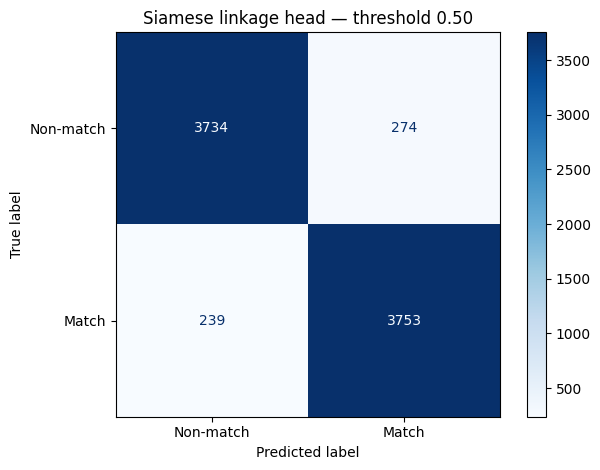

Saved Siamese models, metrics, predictions and histories:
C:\Users\fayya\OneDrive\Documents\GitHub\COMP3850\Group-63-COMP3850\results\linkage_20260923_105041_342950\siamese_head


In [11]:
# Save the Siamese baseline separately from the direct-embedding MLP.
# A timestamped folder preserves results from earlier executions.
from datetime import datetime

baseline_run_dir = Path("results") / (
    "linkage_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f")
)
siamese_results_dir = baseline_run_dir / "siamese_head"
siamese_results_dir.mkdir(parents=True, exist_ok=False)

# Plot the predictions already calculated in the previous cell.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    siamese_test_pred,
    labels=[0, 1],
    display_labels=["Non-match", "Match"],
    cmap="Blues",
    values_format="d",
)
plt.title("Siamese linkage head — threshold 0.50")
plt.tight_layout()
plt.savefig(
    siamese_results_dir / "confusion_matrix.png",
    dpi=150,
)
plt.show()

# Both components are needed to predict from original embeddings.
encoder.save(str(siamese_results_dir / "encoder.keras"))
siamese_head.save(str(siamese_results_dir / "linkage_head.keras"))

with (siamese_results_dir / "metrics.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(siamese_metrics, file, indent=2)

# Preserve test-row identity alongside predictions.
assert len(test_df) == len(y_test) == len(siamese_test_prob)

test_predictions = test_df[["uid1", "uid2"]].reset_index(drop=True).copy()
test_predictions.insert(0, "embedding_row", np.arange(len(y_test)))
test_predictions["true_label"] = y_test
test_predictions["predicted_label"] = siamese_test_pred
test_predictions["match_probability"] = siamese_test_prob
test_predictions.to_csv(
    siamese_results_dir / "test_predictions.csv",
    index=False,
)

# Save training histories and the earlier fixed-distance baseline.
pd.DataFrame(siamese_history.history).to_csv(
    siamese_results_dir / "encoder_training_history.csv",
    index=False,
)
pd.DataFrame(siamese_head_history.history).to_csv(
    siamese_results_dir / "head_training_history.csv",
    index=False,
)
distance_results.to_csv(
    siamese_results_dir / "fixed_distance_metrics.csv",
    index=False,
)

print("Saved Siamese models, metrics, predictions and histories:")
print(siamese_results_dir.resolve())

In [12]:
# Baseline 3: MLP using original embedding differences.
# This model does not use the trained Siamese encoder.

direct_diff_train = np.abs(x1_train - x2_train)
direct_diff_test = np.abs(x1_test - x2_test)

# Reserve 20% of training pairs exclusively for threshold selection.
# Save indices so the split can be traced back to the source rows.
direct_fit_idx, direct_threshold_idx = train_test_split(
    np.arange(len(y_train)),
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

assert not np.intersect1d(
    direct_fit_idx, direct_threshold_idx
).size

direct_fit_features = direct_diff_train[direct_fit_idx]
direct_fit_labels = y_train[direct_fit_idx]
direct_threshold_features = direct_diff_train[direct_threshold_idx]
direct_threshold_labels = y_train[direct_threshold_idx]

# Preserve the original architecture and regularisation.
direct_input = Input(shape=(direct_diff_train.shape[1],))
hidden = Dense(
    64, activation="relu",
    kernel_regularizer=regularizers.l2(0.01),
)(direct_input)
hidden = Dropout(0.5)(hidden)
hidden = Dense(
    32, activation="relu",
    kernel_regularizer=regularizers.l2(0.01),
)(hidden)
direct_output = Dense(1, activation="sigmoid")(hidden)

direct_mlp = Model(direct_input, direct_output)
direct_mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# An additional 10% of the 80% fitting subset monitors training.
# The threshold-selection subset and external test set are excluded.
direct_history = direct_mlp.fit(
    direct_fit_features,
    direct_fit_labels,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    verbose=2,
    callbacks=[tf.keras.callbacks.TerminateOnNaN()],
)

assert np.isfinite(direct_history.history["loss"]).all()
assert np.isfinite(direct_history.history["val_loss"]).all()

# Select the threshold using validation F1 only.
direct_threshold_prob = direct_mlp.predict(
    direct_threshold_features, verbose=0
).ravel()

assert np.isfinite(direct_threshold_prob).all()

threshold_rows = []
for threshold in np.arange(0.1, 0.9, 0.01):
    predictions = (
        direct_threshold_prob >= threshold
    ).astype(int)

    threshold_rows.append({
        "threshold": float(threshold),
        "validation_f1": float(
            f1_score(
                direct_threshold_labels,
                predictions,
                zero_division=0,
            )
        ),
    })

direct_threshold_search = pd.DataFrame(threshold_rows)

# In a tie, select the first (lowest) threshold in the search grid.
best_row = direct_threshold_search.loc[
    direct_threshold_search["validation_f1"].idxmax()
]
direct_threshold = float(best_row["threshold"])

print("Selected threshold:", f"{direct_threshold:.2f}")
print("Threshold-validation F1:", f"{best_row['validation_f1']:.4f}")

# Evaluate the external test set using the selected threshold.
direct_test_prob = direct_mlp.predict(
    direct_diff_test, verbose=0
).ravel()

assert np.isfinite(direct_test_prob).all()
assert ((direct_test_prob >= 0) & (direct_test_prob <= 1)).all()

direct_test_pred = (
    direct_test_prob >= direct_threshold
).astype(int)

direct_metrics = {
    "model": "MLP on absolute differences of original BERT embeddings",
    "task": "record linkage",
    "threshold": direct_threshold,
    "decision_rule": "probability >= threshold",
    "threshold_validation_f1": float(best_row["validation_f1"]),
    "test_accuracy": float(
        accuracy_score(y_test, direct_test_pred)
    ),
    "test_f1": float(
        f1_score(y_test, direct_test_pred, zero_division=0)
    ),
    "test_roc_auc": float(
        roc_auc_score(y_test, direct_test_prob)
    ),
    "test_pairs": int(len(y_test)),
}

print("\nDirect-embedding MLP — test evaluation")
print(f"Accuracy: {direct_metrics['test_accuracy']:.4f}")
print(f"F1:       {direct_metrics['test_f1']:.4f}")
print(f"ROC AUC:  {direct_metrics['test_roc_auc']:.4f}")
print(
    "\n",
    classification_report(
        y_test,
        direct_test_pred,
        labels=[0, 1],
        target_names=["Non-match", "Match"],
        zero_division=0,
    ),
)

Epoch 1/30
90/90 - 2s - loss: 1.2723 - accuracy: 0.7462 - val_loss: 0.7187 - val_accuracy: 0.8473 - 2s/epoch - 27ms/step
Epoch 2/30
90/90 - 0s - loss: 0.6094 - accuracy: 0.8488 - val_loss: 0.4908 - val_accuracy: 0.8750 - 487ms/epoch - 5ms/step
Epoch 3/30
90/90 - 0s - loss: 0.4708 - accuracy: 0.8653 - val_loss: 0.4089 - val_accuracy: 0.8891 - 460ms/epoch - 5ms/step
Epoch 4/30
90/90 - 0s - loss: 0.4183 - accuracy: 0.8734 - val_loss: 0.3761 - val_accuracy: 0.8906 - 406ms/epoch - 5ms/step
Epoch 5/30
90/90 - 0s - loss: 0.3960 - accuracy: 0.8729 - val_loss: 0.3650 - val_accuracy: 0.8867 - 443ms/epoch - 5ms/step
Epoch 6/30
90/90 - 0s - loss: 0.3824 - accuracy: 0.8747 - val_loss: 0.3563 - val_accuracy: 0.8906 - 440ms/epoch - 5ms/step
Epoch 7/30
90/90 - 0s - loss: 0.3721 - accuracy: 0.8791 - val_loss: 0.3476 - val_accuracy: 0.8973 - 430ms/epoch - 5ms/step
Epoch 8/30
90/90 - 0s - loss: 0.3688 - accuracy: 0.8760 - val_loss: 0.3462 - val_accuracy: 0.8887 - 379ms/epoch - 4ms/step
Epoch 9/30
90/90 -

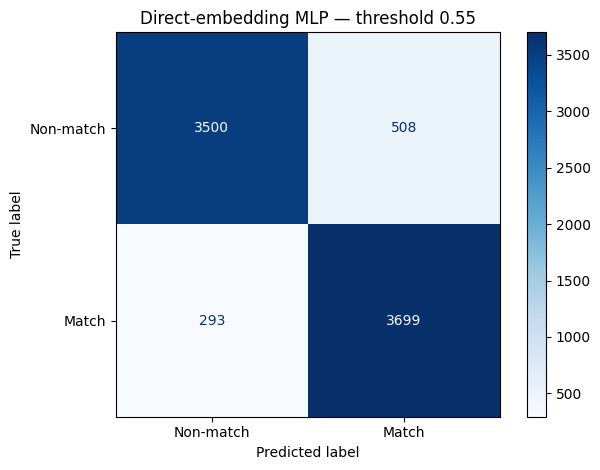


Record-linkage baseline comparison:
                          model  test_accuracy  test_f1
Siamese fixed-distance baseline       0.917500 0.914970
           Siamese linkage head       0.935875 0.936027
           Direct-embedding MLP       0.899875 0.902305

Saved results: C:\Users\fayya\OneDrive\Documents\GitHub\COMP3850\Group-63-COMP3850\results\linkage_20260923_105041_342950


In [13]:
# Save this baseline alongside the Siamese results from the same run.
direct_results_dir = baseline_run_dir / "direct_embedding_mlp"
direct_results_dir.mkdir(parents=True, exist_ok=False)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    direct_test_pred,
    labels=[0, 1],
    display_labels=["Non-match", "Match"],
    cmap="Blues",
    values_format="d",
)
plt.title(
    f"Direct-embedding MLP — threshold {direct_threshold:.2f}"
)
plt.tight_layout()
plt.savefig(
    direct_results_dir / "confusion_matrix.png",
    dpi=150,
)
plt.show()

direct_mlp.save(str(direct_results_dir / "model.keras"))

with (direct_results_dir / "metrics.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(direct_metrics, file, indent=2)

# Preserve the source-row identity of each test prediction.
assert len(test_df) == len(y_test) == len(direct_test_prob)

direct_predictions = (
    test_df[["uid1", "uid2"]].reset_index(drop=True).copy()
)
direct_predictions.insert(
    0, "embedding_row", np.arange(len(y_test))
)
direct_predictions["true_label"] = y_test
direct_predictions["predicted_label"] = direct_test_pred
direct_predictions["match_probability"] = direct_test_prob
direct_predictions.to_csv(
    direct_results_dir / "test_predictions.csv",
    index=False,
)

pd.DataFrame(direct_history.history).to_csv(
    direct_results_dir / "training_history.csv",
    index=False,
)
direct_threshold_search.to_csv(
    direct_results_dir / "threshold_search.csv",
    index=False,
)

# Keras reserves the final 10% of the fitting subset for validation.
split_at = int(len(direct_fit_idx) * 0.9)
np.savez(
    direct_results_dir / "split_indices.npz",
    optimiser_train=direct_fit_idx[:split_at],
    training_validation=direct_fit_idx[split_at:],
    threshold_validation=direct_threshold_idx,
)

# Compare the three linkage baselines on the same external test set.
distance_test = distance_results.loc[
    distance_results["split"] == "Test split"
].iloc[0]

baseline_comparison = pd.DataFrame([
    {
        "model": "Siamese fixed-distance baseline",
        "test_accuracy": float(distance_test["accuracy"]),
        "test_f1": float(distance_test["f1"]),
    },
    {
        "model": "Siamese linkage head",
        "test_accuracy": siamese_metrics["test_accuracy"],
        "test_f1": siamese_metrics["test_f1"],
    },
    {
        "model": "Direct-embedding MLP",
        "test_accuracy": direct_metrics["test_accuracy"],
        "test_f1": direct_metrics["test_f1"],
    },
])
baseline_comparison.to_csv(
    baseline_run_dir / "baseline_comparison.csv",
    index=False,
)

print("\nRecord-linkage baseline comparison:")
print(baseline_comparison.to_string(index=False))
print("\nSaved results:", baseline_run_dir.resolve())

## Historical results — 23 September 2026

All three record-linkage baselines were evaluated on the same
8,000-pair target test split.

| Baseline | Test accuracy | Test F1 |
|---|---:|---:|
| Siamese fixed-distance | 91.75% | 0.9150 |
| Siamese classification head | 93.59% | 0.9360 |
| Direct-embedding MLP | 89.99% | 0.9023 |

The Siamese classification head achieved the highest test accuracy
and F1 in this run. The direct-embedding MLP used a threshold of 0.55,
selected using its threshold-validation subset.

These are record-linkage results, not membership-inference results.
The separate shadow-model experiment retains its original target and
attack evaluations.

This comparison reflects one execution. The models use different
training procedures, and repeated runs would be needed to assess
performance variability.

Saved artifacts: `results/linkage_20260923_105041_342950/`.